## 야후 파이넨스(yfinance)
- yfinance는 전 세계 주식, ETF, 암호화폐의 실시간 및 과거데이터를 코드 한 줄로 내 파이썬 노트북에 가져와 주는 "무료 금융 데이터 치트키" 라이브러리 입니다.
- 기존에 사이트엣 CSV파일을 다운로드 할 수 있지만, 종목이 많아지면 관리하기 어렵기 때문에 라이브러리 사용을 권장합니다.

[야후 파이넨스 공식 링크](https://finance.yahoo.com/)

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

warnings.filterwarnings('ignore')

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [8]:
session = cffi_requests.Session(impersonate="chrome")

tickers = ["JEPQ", "JEPI", "NVDA", "MSFT"]
all_data = {}

for t in tickers:
    df = yf.download(t, start="2024-01-01", end="2026-09-01", session=session, threads=False)
    all_data[t] = df
    time.sleep(5)

all_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


{'JEPQ': Price           Close       High        Low       Open   Volume
 Ticker           JEPQ       JEPQ       JEPQ       JEPQ     JEPQ
 Date                                                           
 2024-01-02  37.038410  37.195320  36.920353  37.195320  3137400
 2024-01-03  36.776905  36.920365  36.732072  36.881512  2316600
 2024-01-04  36.627457  36.874029  36.612512  36.664816  2790100
 2024-01-05  36.724594  36.896448  36.612514  36.642402  2798000
 2024-01-08  37.284985  37.292455  36.806778  36.814252  2124500
 ...               ...        ...        ...        ...      ...
 2026-08-25  59.072330  59.220631  58.849884  59.092104  4602500
 2026-08-26  59.111877  59.210742  58.924030  58.943804  4441800
 2026-08-27  59.625980  59.643774  59.279948  59.448022  4667600
 2026-08-28  59.467796  59.823710  59.388702  59.586434  6185300
 2026-08-31  59.537003  59.566661  59.319497  59.467797  8095700
 
 [668 rows x 5 columns],
 'JEPI': Price           Close       High        Low   

In [9]:
all_data["NVDA"].head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.028790,49.152531,47.457447,49.101680,411254000
2024-01-03,47.431526,48.044747,47.183245,47.347769,320896000
2024-01-04,47.859283,48.359832,47.370698,47.628948,306535000
2024-01-05,48.955101,49.403801,48.166387,48.321938,415039000
2024-01-08,52.101990,52.123929,49.336008,49.368914,642510000


In [10]:
all_data["NVDA"].columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

## 데이터 준비

In [13]:
close_df = pd.DataFrame()

for t in tickers:
    close_df[t] = all_data[t]["Close"]

print(close_df)

                 JEPQ       JEPI        NVDA        MSFT
Date                                                    
2024-01-02  37.038410  44.692692   48.028790  363.117920
2024-01-03  36.776905  44.441349   47.431526  362.853607
2024-01-04  36.627457  44.425133   47.859283  360.249176
2024-01-05  36.724594  44.392693   48.955101  360.063141
2024-01-08  37.284985  44.692692   52.101990  366.858124
...               ...        ...         ...         ...
2026-08-25  59.072330  57.764870  212.811874  491.709991
2026-08-26  59.111877  57.784740  209.425659  496.369995
2026-08-27  59.625980  57.476738  227.725174  505.059998
2026-08-28  59.467796  57.417130  217.306839  513.530029
2026-08-31  59.537003  57.128998  220.533234  507.290009

[668 rows x 4 columns]


## 데이터 전처리

In [14]:
close_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 668 entries, 2024-01-02 to 2026-08-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JEPQ    668 non-null    float64
 1   JEPI    668 non-null    float64
 2   NVDA    668 non-null    float64
 3   MSFT    668 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [15]:
close_df.describe()

,JEPQ,JEPI,NVDA,MSFT
count,668.000000,668.000000,668.000000,668.000000
mean,47.879984,51.286076,147.299539,431.921962
std,6.121774,3.362890,43.831636,44.189094
min,36.627457,44.392693,47.431526,350.446045
25%,42.768605,48.528728,115.916481,400.007027
50%,47.085592,51.441774,141.016624,417.746292
75%,53.268999,54.248924,183.702614,470.046600
max,59.873146,57.784740,235.202393,537.646362


## 초기 가설
- NVDA, MSFT 개별 성장주이기 때문에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다.
- JEPQ, JEPI 배당형 성장형 ETF이기 때문에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다.
- 2024년도 조정기에 ETF 중 표준편차가 낮은 JEPI가 가장 방어력이 좋았을 것이다.

In [18]:
# .pct_change(): 변화율을 구해주는 함수
# ex) (오늘 종가 - 어제 종가) / 어제 종가

returns_df = close_df.pct_change().dropna()
returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.004064,-0.000365,0.009018,-0.007178
2024-01-05,0.002652,-0.000730,0.022897,-0.000516
2024-01-08,0.015259,0.006758,0.064281,0.018872
2024-01-09,0.002204,-0.000726,0.016975,0.002935
...,...,...,...,...
2026-08-25,0.005554,0.000861,0.021921,0.009029
2026-08-26,0.000669,0.000344,-0.015912,0.009477
2026-08-27,0.008697,-0.005330,0.087380,0.017507


In [21]:
# cumprod
cum_returns_df = (1 + returns_df).cumprod() - 1
cum_returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006712,0.019287,-0.008413
2024-01-08,0.006657,0.000000,0.084807,0.010300
2024-01-09,0.008876,-0.000726,0.103222,0.013266
...,...,...,...,...
2026-08-25,0.594894,0.292490,3.430923,0.354133
2026-08-26,0.595962,0.292935,3.360419,0.366966
2026-08-27,0.609842,0.286043,3.741431,0.390898


In [23]:
# cummax: 이전 값과 비교하여 최고 값으로 대체
peak_df = close_df.cummax()
peak_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,37.038410,44.692692,48.028790,363.117920
2024-01-03,37.038410,44.692692,48.028790,363.117920
2024-01-04,37.038410,44.692692,48.028790,363.117920
2024-01-05,37.038410,44.692692,48.955101,363.117920
2024-01-08,37.284985,44.692692,52.101990,366.858124
...,...,...,...,...
2026-08-25,59.873146,57.764870,235.202393,537.646362
2026-08-26,59.873146,57.784740,235.202393,537.646362
2026-08-27,59.873146,57.784740,235.202393,537.646362


In [24]:
# 고점 대비 낙폭
drawdown_df = (close_df - peak_df) / peak_df
drawdown_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,0.000000,0.000000,0.000000,0.000000
2024-01-03,-0.007060,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006712,0.000000,-0.008413
2024-01-08,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2026-08-25,-0.013375,0.000000,-0.095197,-0.085440
2026-08-26,-0.012715,0.000000,-0.109594,-0.076772
2026-08-27,-0.004128,-0.005330,-0.031791,-0.060609


In [36]:
# 수익의 변동성(표준편차) * 미국 주식(252) - 휴장일을 제외한 미국의 주식 일수
# 연율화(미국 주식의 "년"단위 변동성)
annual_vol = returns_df.std() * np.sqrt(252)
annual_vol

mdd = drawdown_df.min()
mdd

v1_proof = pd.DataFrame({
    "최종 누적 수익률(%)": cum_returns_df.iloc[-1] * 100,
    "연율화 변동성(%)": annual_vol * 100,
    "최대 낙폭 MDD(%)": mdd * 100
})

v1_proof

,최종 누적 수익률(%),연율화 변동성(%),최대 낙폭 MDD(%)
JEPQ,60.743947,16.137034,-20.069893
JEPI,27.826263,10.279523,-13.257861
NVDA,359.168836,48.437017,-36.881027
MSFT,39.703931,26.850658,-34.498390


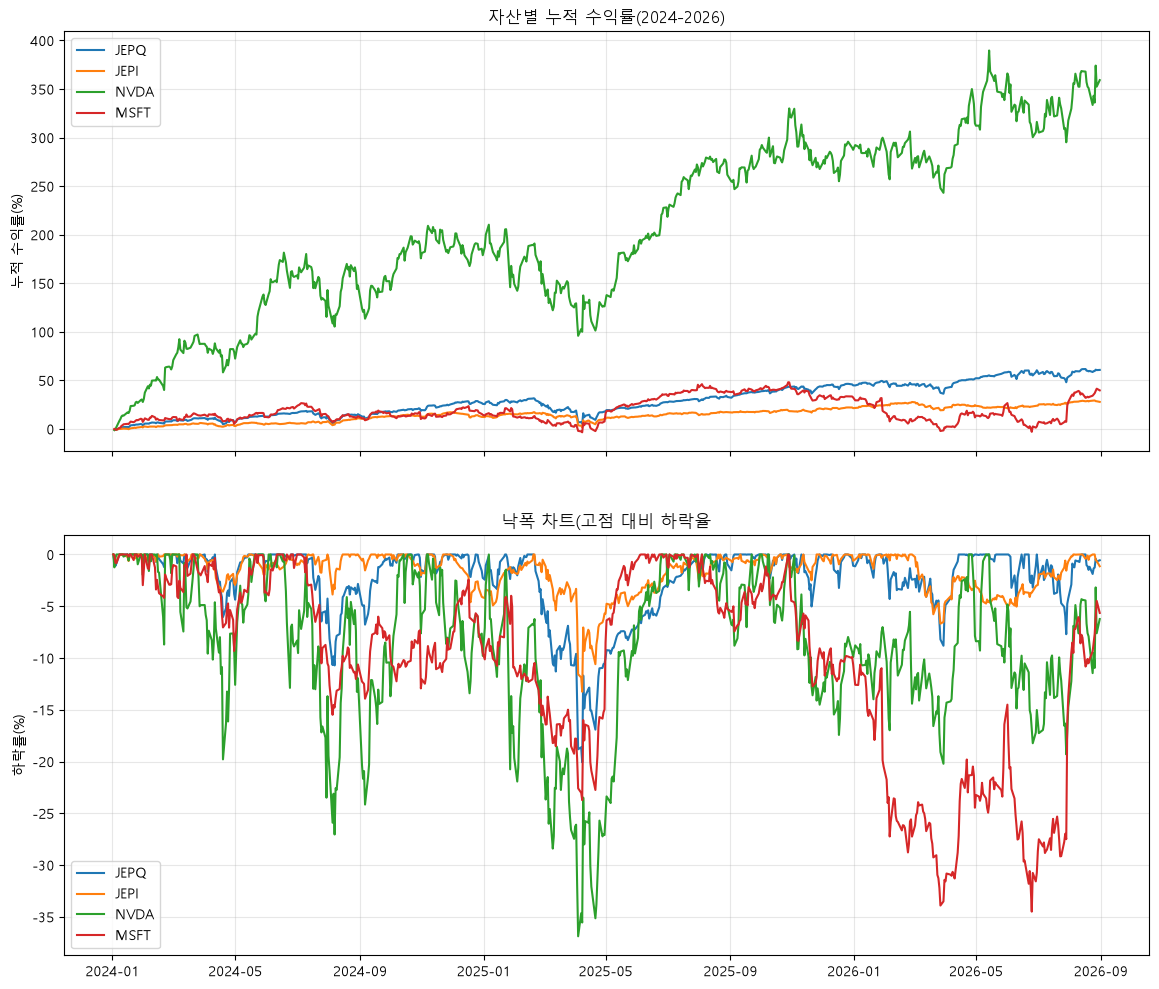

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for t in tickers:
    # x축: cum_returns_df.index(일자), y축: cum_returns_df[t] * 100 값
    axes[0].plot(cum_returns_df.index, cum_returns_df[t] * 100, label=t)
    axes[0].set_title("자산별 누적 수익률(2024-2026)")
    axes[0].set_ylabel("누적 수익률(%)")
    axes[0].legend()
    # alpha=0.3: 투명도 30%
    axes[0].grid(True, alpha=0.3)

for t in tickers:
    axes[1].plot(drawdown_df.index, drawdown_df[t] * 100, label=t)
    axes[1].set_title("낙폭 차트(고점 대비 하락율")
    axes[1].set_ylabel("하락률(%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.show()

가설: NVDA, MSFT 개별 성장주이기 때문에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다.  
JEPQ, JEPI 배당형 성장형 ETF이기 때문에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다.  
2024년도 조정기에 ETF 중 표준편차가 낮은 JEPI가 가장 방어력이 좋았을 것이다.

검증: NVDA, MSFT 개별 성장주는 각각 36.8%, 34.4%의 최고 하락률을 기록하고 있지만, 반면 JEPI ETF는 최대 하락률이 13.2%로 2.8배가량 차이가 난다.  
JEPI는 주가 하락의 방어가 가장 좋은 ETF 주식이다.  
가설은 참(채택)

## 가설2
- JEPQ, JEPI 배당형 ETF,
- JEPQ는 나스닥 100 기반으로 상장된 ETF이므로 NVDA, MSFT와 높은 상관관계를 가질 것이다.
- JEPI는 S&P 500 기반으로 상장된 ETF이므로, NVDA, MSFT 낮은 상관관계를 가질 것이다.

In [50]:
# .rolling()
# .corr(): 최근 20일간의 상관관계를 ㅁ일 계산해서 반환
rolling_jepi = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPI"])
rolling_jepq = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPQ"])

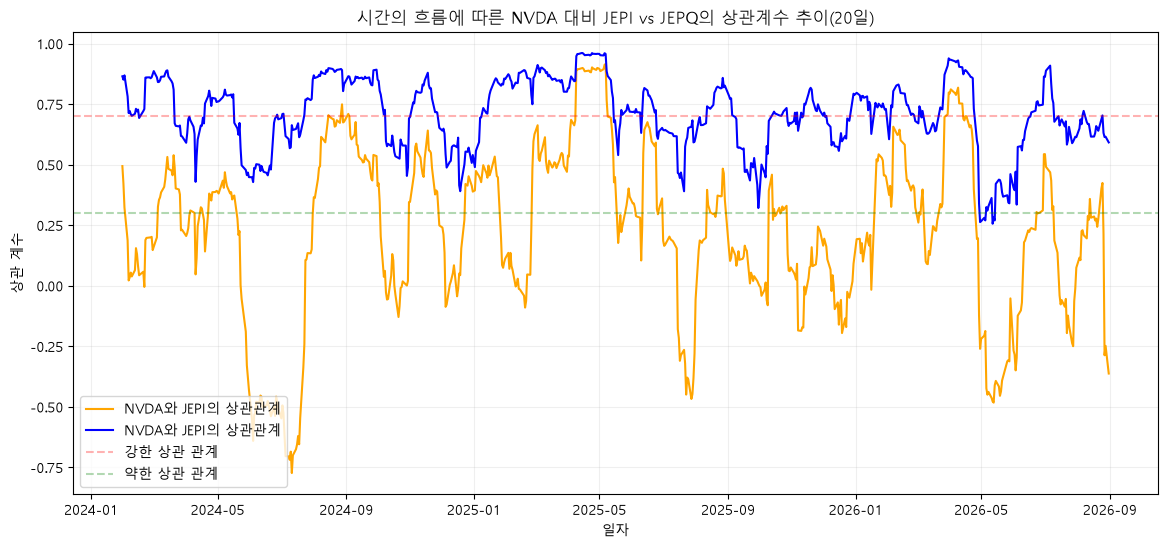

In [62]:
plt.figure(figsize=(14, 6))
plt.plot(rolling_jepi.index, rolling_jepi, label="NVDA와 JEPI의 상관관계", color="orange")
plt.plot(rolling_jepq.index, rolling_jepq, label="NVDA와 JEPI의 상관관계", color="blue")

plt.axhline(0.7, color="red", linestyle="--", alpha=0.3, label="강한 상관 관계")
plt.axhline(0.3, color="green", linestyle="--", alpha=0.3, label="약한 상관 관계")

plt.title("시간의 흐름에 따른 NVDA 대비 JEPI vs JEPQ의 상관계수 추이(20일)")
plt.ylabel("상관 계수")
plt.xlabel("일자")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)
plt.show()

## 가설 검증 결과
- JEPQ와 NVDA는 지속적 0.7이상의 높은 상관관계를 유지하며 동조화가 잘 되고 있다.
- 반대로 JEPI는 NVDA와의 상관관계가 0.4이상의 낮은 상관관계를 유지하며 동조화가 되고 있다.
- 성장주(NVDA) 리스크 분산을 하고 싶을 때에는 JEPI를 추천해서 자산을 배분해야한다.
- 가설은 참, 가설 채택

## EDA 시각화
역사적 고점 대비 대략 20%가 떨어졌을 때 사면, 이후 한달 뒤에 얼마정도의 수익을 볼 확률, 평균 수익률은 어떻게 될까?

In [77]:
forward_days = 20
results = []

for t in tickers:
    # 20일 뒤 주가 / 현재 주가 - 1(20일동안의 수익율)
    fwd_return_df = (close_df[t].shift(-forward_days) / close_df[t]) - 1
    drawdown = drawdown_df[t]
    df_temp = pd.DataFrame({"Drawdown": drawdown, "FwdReturn": fwd_return_df}).dropna()

    # 구간
    bins = [-1.0, -0.2, -0.1, -0.05, 0.001]
    labels = ["-20% 이하(대폭락)", "-10% ~ -20%", "-5% ~ -10%", "-0% ~ -5%"]

    df_temp["구간"] = pd.cut(df_temp["Drawdown"], bins=bins, labels=labels)

    # 구간별 통계 집계
    for label in labels:
        sub_df = df_temp[df_temp["구간"] == label]

        if len(sub_df) > 0:
            win_rate = (sub_df["FwdReturn"] > 0).mean() * 100  # 수익을 볼 확률
            avg_rate = sub_df["FwdReturn"].mean() * 100  # 평균 수익율(%)

            results.append({
                "종목": t,
                "낙폭 구간": label,
                "진입 횟수(일)": len(sub_df),
                "1개월 뒤 승률(%)": win_rate,
                "1개월 뒤 평균 수익률(%)": avg_rate
            })

prob_df = pd.DataFrame(results)
prob_df

,종목,낙폭 구간,진입 횟수(일),1개월 뒤 승률(%),1개월 뒤 평균 수익률(%)
0,JEPQ,-20% 이하(대폭락),1,100.000000,13.483989
1,JEPQ,-10% ~ -20%,27,77.777778,3.940406
2,JEPQ,-5% ~ -10%,80,78.750000,2.140767
3,JEPQ,-0% ~ -5%,540,73.518519,1.201905
4,JEPI,-10% ~ -20%,4,100.000000,8.186326
5,JEPI,-5% ~ -10%,23,95.652174,2.954740
6,JEPI,-0% ~ -5%,621,70.531401,0.660211
7,NVDA,-20% 이하(대폭락),63,66.666667,9.943813
8,NVDA,-10% ~ -20%,176,73.863636,4.830248
9,NVDA,-5% ~ -10%,169,45.562130,0.567435


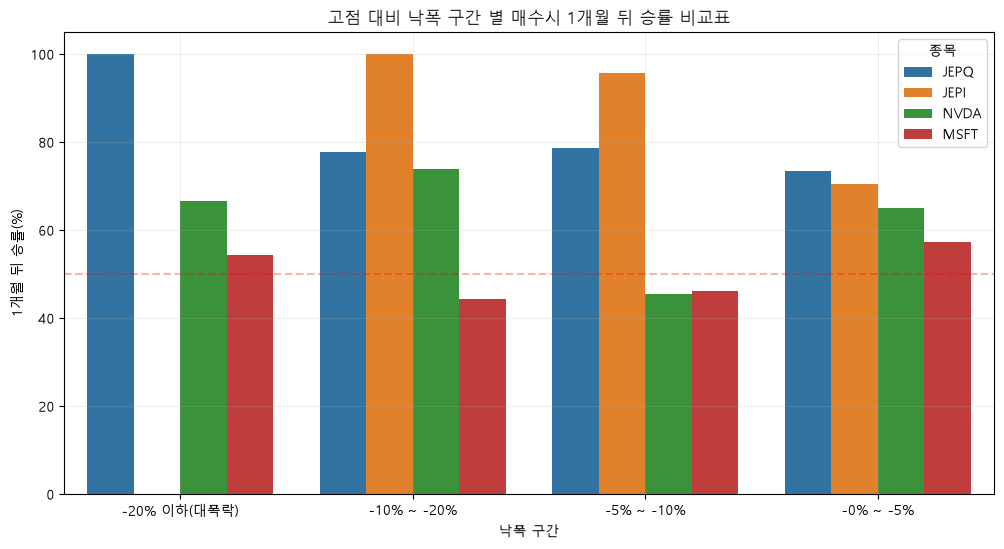

In [80]:
plt.figure(figsize=(12, 6))

sns.barplot(data=prob_df, x="낙폭 구간", y="1개월 뒤 승률(%)", hue="종목")

plt.axhline(50, color="red", linestyle="--", alpha=0.3)

plt.title("고점 대비 낙폭 구간 별 매수시 1개월 뒤 승률 비교표")
plt.grid(True, alpha=0.2)
plt.show()

## 결론
- 개별 성장주의 조정기(-10% ~ -20%)에도 수익률 보다 ETF 주식의 조정기 수익률이 극대화되며 대략 JEPQ는 약 13.4%이며, 승률도 극대화 되었다.
- 개별 성장주의 (-5% ~ -10%) 구간에서는 오히려 승률이 0.5%보다 낮게 기록되었다.
- 지수형 커버드콜(JEPQ) ETF는 -20%이하 대폭락이 왔을 때 개별 성장주를 압도하는 리턴과 승률을 안겨주는 인사이트를 제공하고 있다.